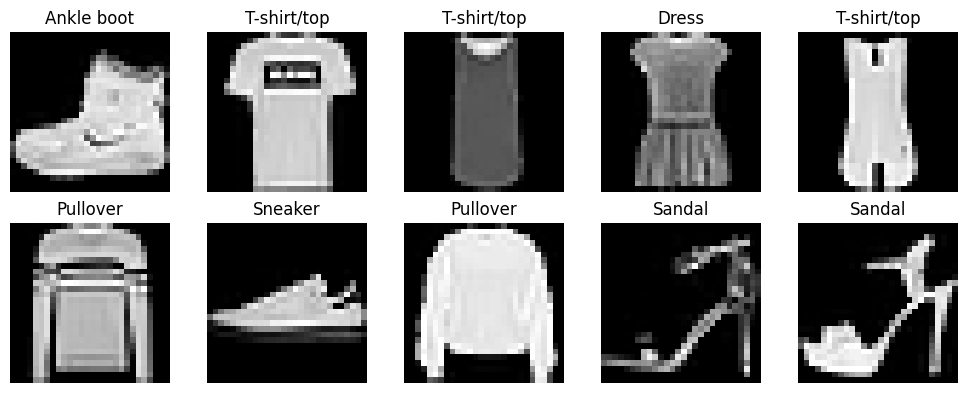

Baseline Accuracy: 0.8339


c:\Users\Matthew\Desktop\цифровая кафедра\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [1]:
# Ячейка 1: Импорт и загрузка
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Ячейка 2: Визуализация
classes = train_set.classes
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i in range(10):
    axes[i//5, i%5].imshow(train_set[i][0].squeeze(), cmap='gray')
    axes[i//5, i%5].set_title(classes[train_set[i][1]])
    axes[i//5, i%5].axis('off')
plt.tight_layout()
plt.show()

# Ячейка 3: Baseline (Логистическая регрессия на сплюснутых пикселях)
X_train = train_set.data.reshape(-1, 28*28).numpy()
y_train = train_set.targets.numpy()
X_test  = test_set.data.reshape(-1, 28*28).numpy()
y_test  = test_set.targets.numpy()

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
preds = lr.predict(X_test)
acc_baseline = accuracy_score(y_test, preds)
print(f"Baseline Accuracy: {acc_baseline:.4f}")

In [2]:
# Ячейка 1: Импорт и DataLoader
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

device = torch.device("cpu")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_loader = DataLoader(datasets.FashionMNIST('./data', train=True, download=True, transform=transform), batch_size=64, shuffle=True)
test_loader  = DataLoader(datasets.FashionMNIST('./data', train=False, transform=transform), batch_size=64)

# Ячейка 2: CNN архитектура
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32*7*7, 64), nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x): return self.net(x)

# Ячейка 3: Обучение
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(3):  # 3 эпохи достаточно для ~90%
    model.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} done")

# Ячейка 4: Оценка и сохранение
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs.to(device))
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
acc_cnn = correct / total
print(f"CNN Accuracy: {acc_cnn:.4f}")

import os; os.makedirs('../artifacts', exist_ok=True)
torch.save(model.state_dict(), '../artifacts/model.pt')
print("Модель сохранена в artifacts/model.pt")

Epoch 1 done
Epoch 2 done
Epoch 3 done
CNN Accuracy: 0.8775
Модель сохранена в artifacts/model.pt
